# **Defining Mean-Reverson (Bolinger) Strategy**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [16]:
company=["BEL.NS","BDL.NS","SBIN.NS","DIXON.NS"]
data=yf.download(company,period="3y",interval="1d")
df=pd.DataFrame(data["Close"])
df

/tmp/ipython-input-3037221509.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(company,period="3y",interval="1d")
[*********************100%***********************]  4 of 4 completed


Ticker,BDL.NS,BEL.NS,DIXON.NS,SBIN.NS
Date,,,,
2023-01-09,459.495575,96.531410,3768.690186,574.743591
2023-01-10,449.082001,95.710892,3725.851074,562.874207
2023-01-11,454.325562,96.724464,3700.037842,564.340149
2023-01-12,460.475677,95.952217,3645.864746,562.637756
2023-01-13,453.198395,96.483139,3621.399658,567.555664
...,...,...,...,...
2026-01-02,1495.000000,403.149994,12165.000000,998.950012
2026-01-05,1541.800049,413.799988,12051.000000,1005.549988
2026-01-06,1542.500000,413.100006,11726.000000,1018.900024


**L201-202: Defininf Mean Reverson (Bollinger) bands:**

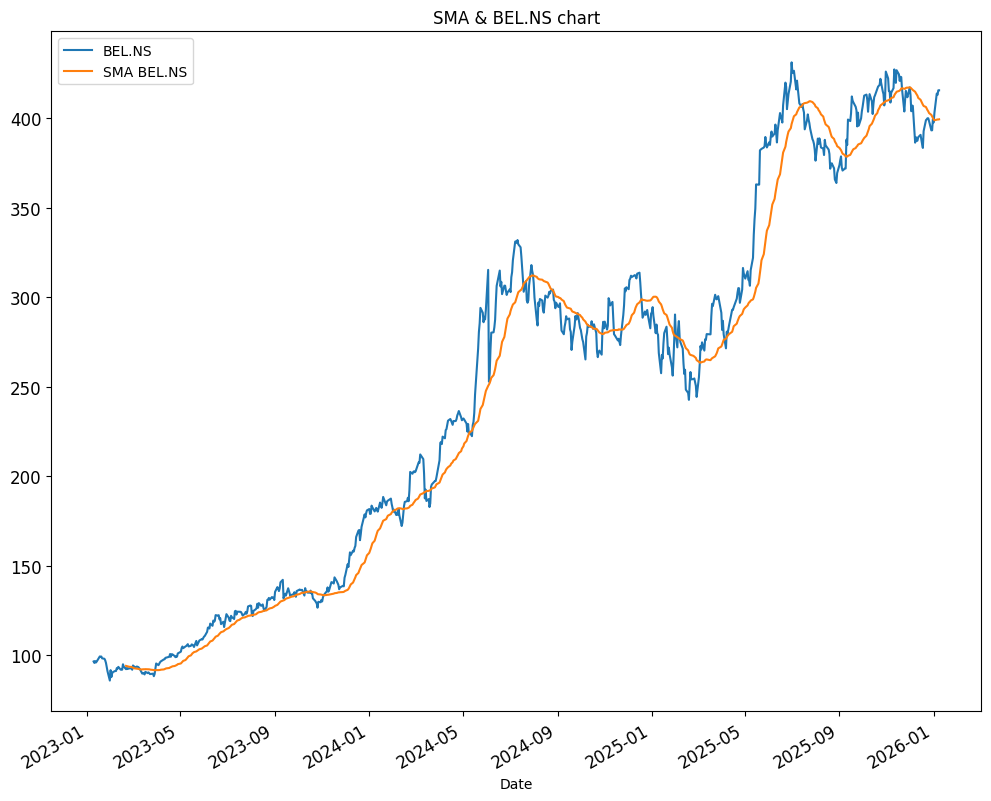

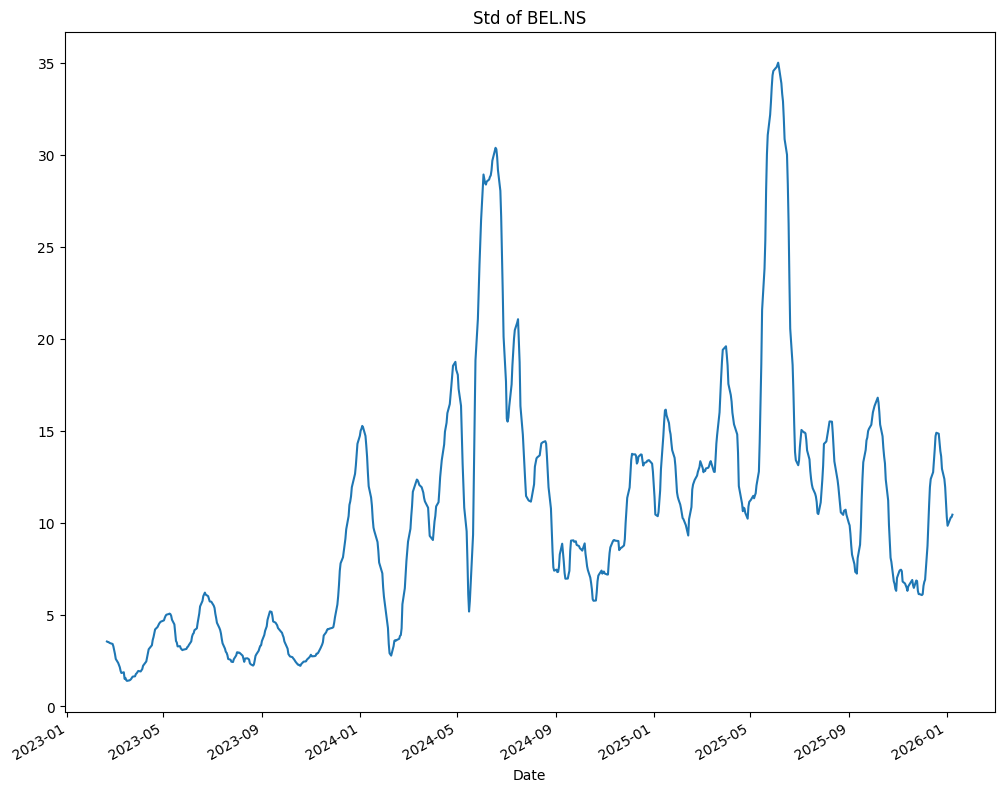

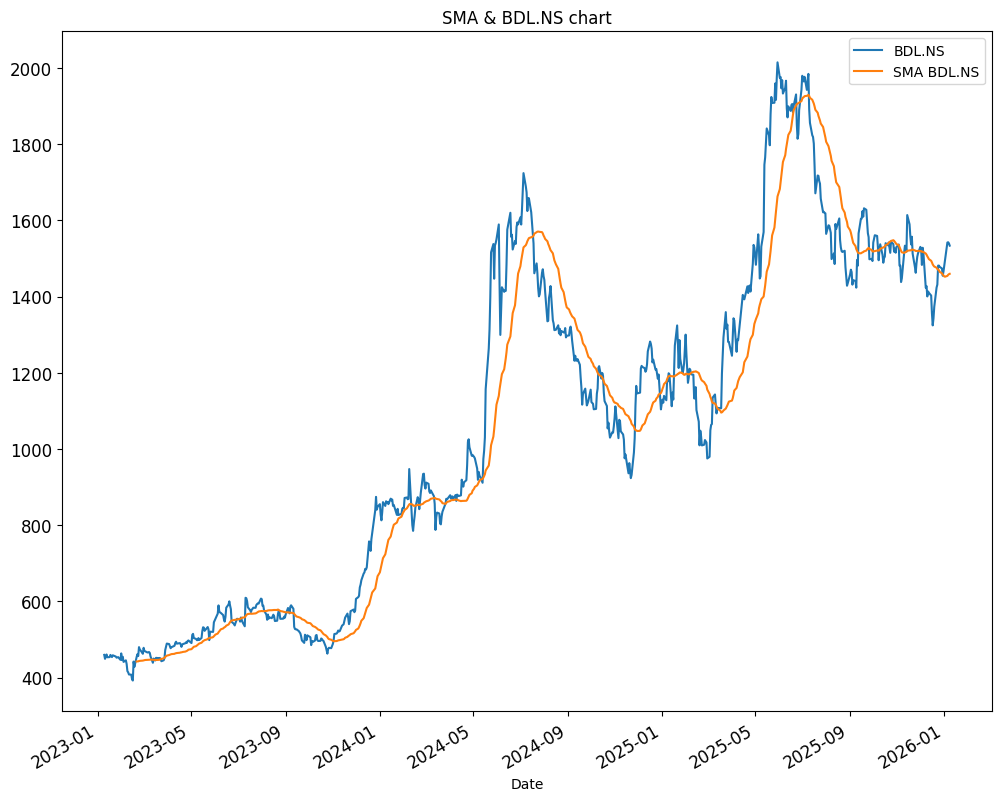

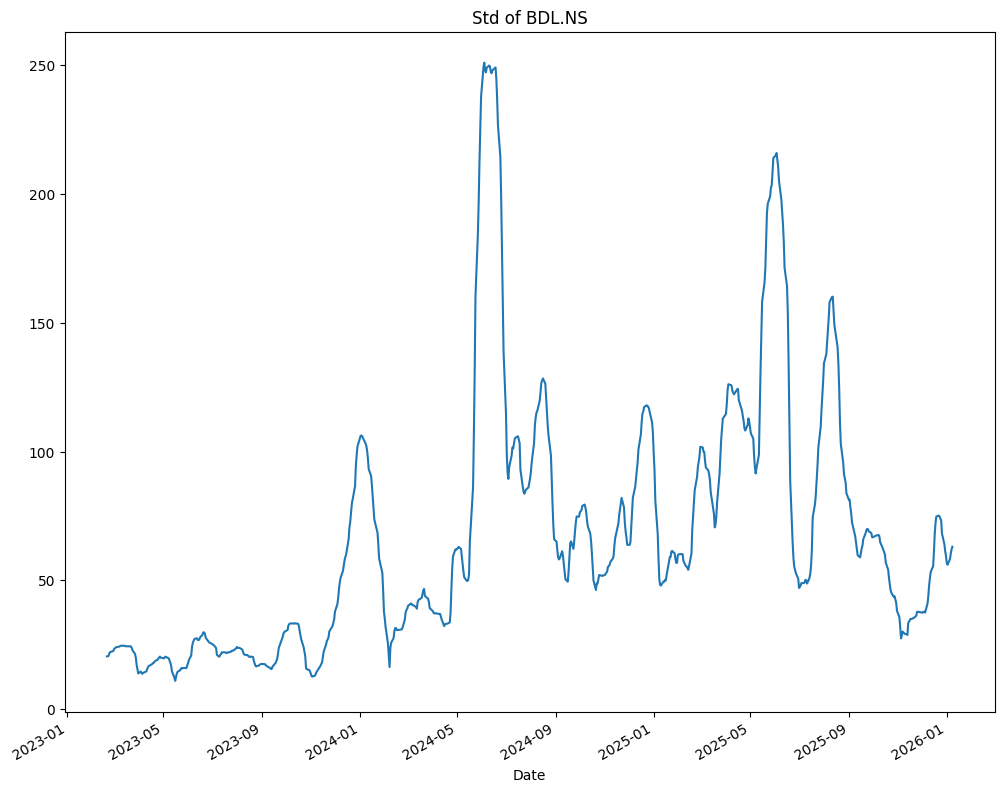

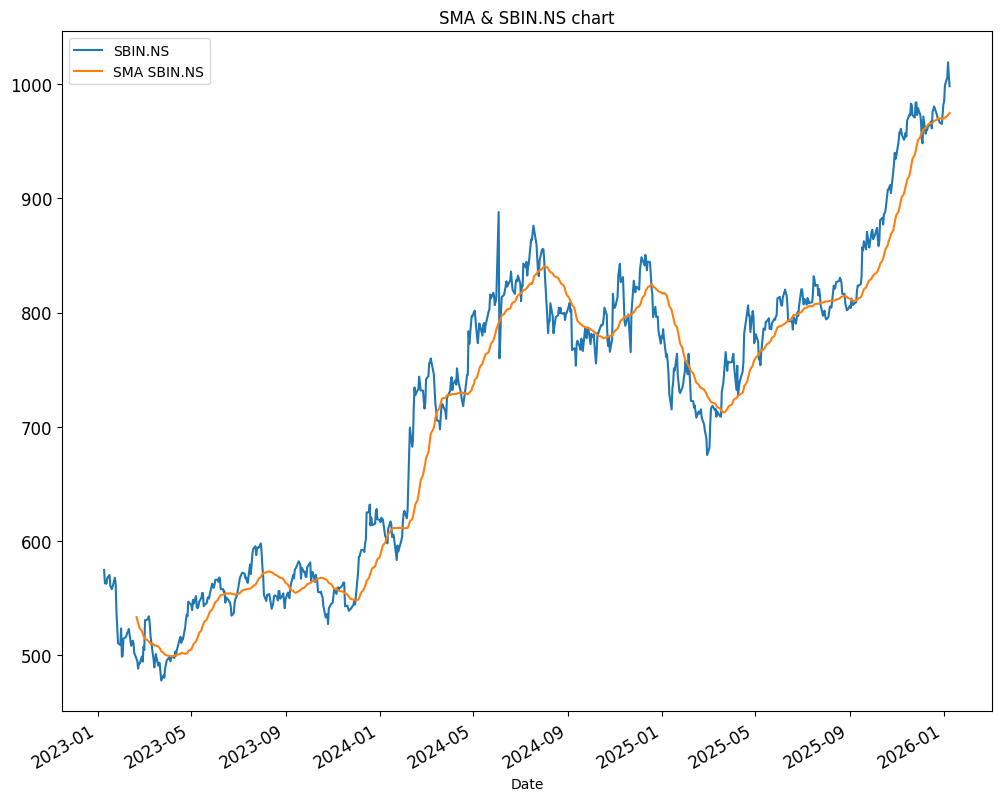

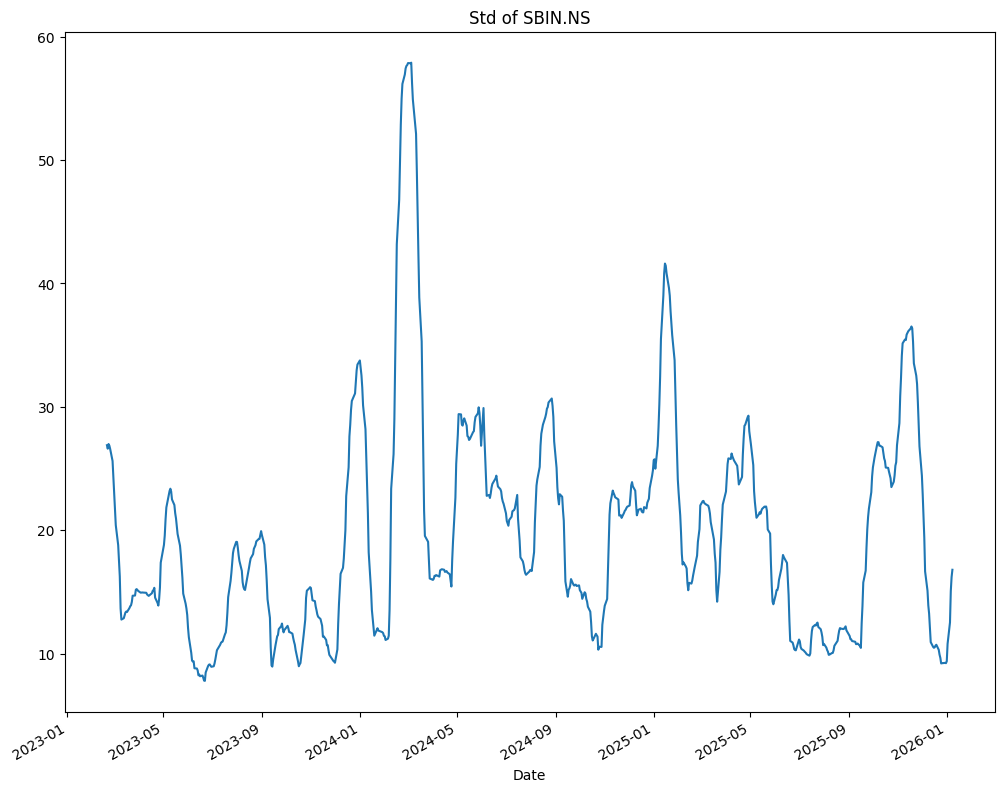

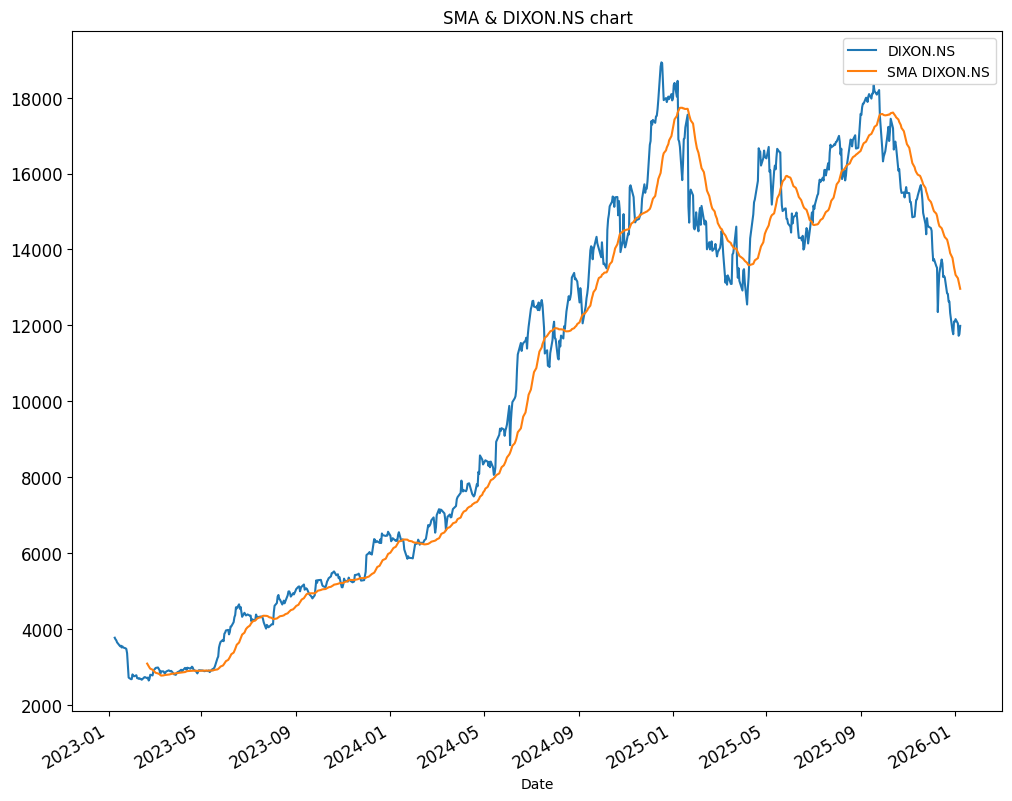

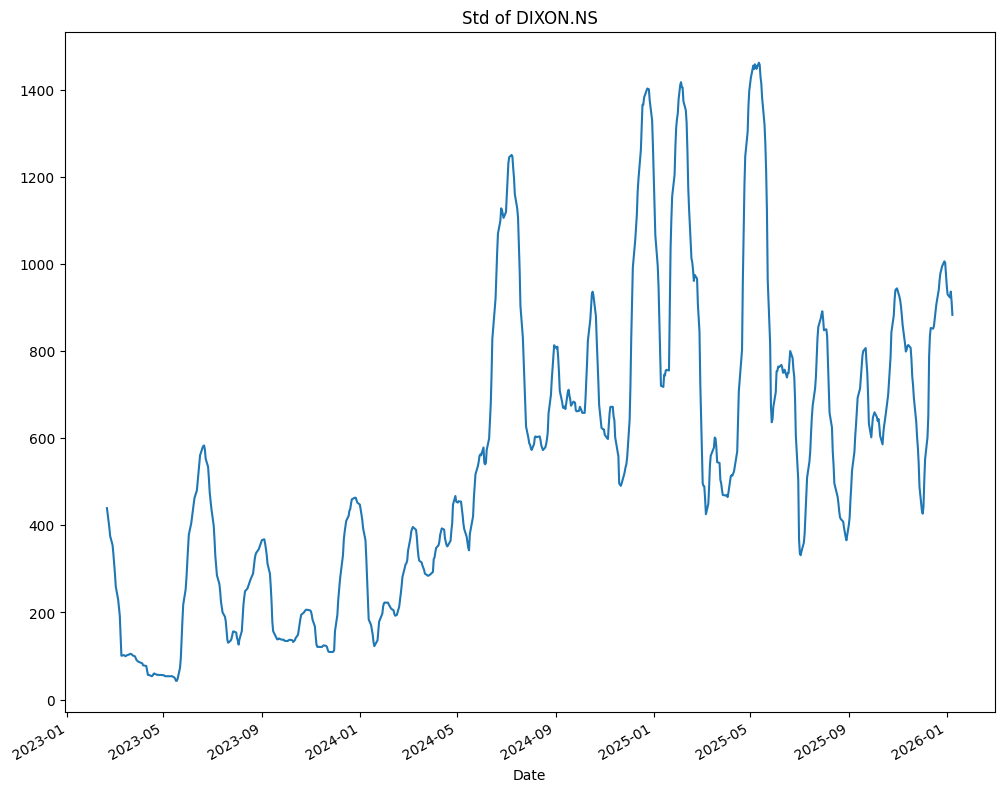

In [17]:
SMA=30;deviation=2
for ticker in company:
  df[f"SMA {ticker}"]=df[ticker].rolling(SMA).mean()
  df[f"{ticker} Lower"]=df[f"SMA {ticker}"]-df[ticker].rolling(SMA).std()*deviation
  df[f"{ticker} Upper"]=df[f"SMA {ticker}"]+df[ticker].rolling(SMA).std()*deviation
  df[f"{ticker} distance"]=df[ticker]-df[f"SMA {ticker}"]
  df[f"{ticker} Position"]=np.where(df[ticker]<df[f"{ticker} Lower"],1,np.nan)
  df[f"{ticker} Position"]=np.where(df[ticker]>df[f"{ticker} Upper"],-1,df[f"{ticker} Position"])
  df[f"{ticker} Position"]=np.where((df[ticker]*df[ticker].shift(1))<0,0,df[f"{ticker} Position"])
  df[f"{ticker} Position"]=df[f"{ticker} Position"].ffill(axis=0)
  df[[ticker,f"SMA {ticker}"]].plot(figsize=(12,10),fontsize=12,title=f"SMA & {ticker} chart",label=[f"{ticker}","SMA"])
  plt.legend()
  plt.show()
  df[ticker].rolling(SMA).std().plot(figsize=(12,10),title=f"Std of {ticker}")
  plt.show()
